In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [16]:
df = pd.read_csv("morphing.csv")

In [17]:
sessions = df["session_uuid"].unique()
sessions

<StringArray>
['696cfac7-4b3e-4701-8229-cada9a2f3f56',
 '94359fbd-8eee-4ac6-af4a-a0e3fff5c48e',
 'a6fcb532-5695-48e9-8ce1-6d9a0795faeb',
 '2972da2a-7403-4a25-8825-c93f4631bbf8',
 '18643d68-5fb8-4606-9e27-1632cdbdf8f4',
 'be207b14-f65a-4609-acac-7142b5b1b443',
 '6b980f92-d2c6-404e-bf27-964e3a3b63ce',
 '57945201-861a-46ee-ba6e-a2ce7832bcdd']
Length: 8, dtype: str

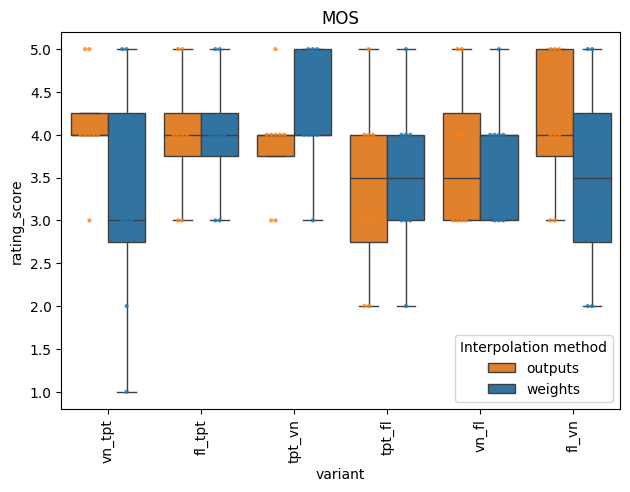

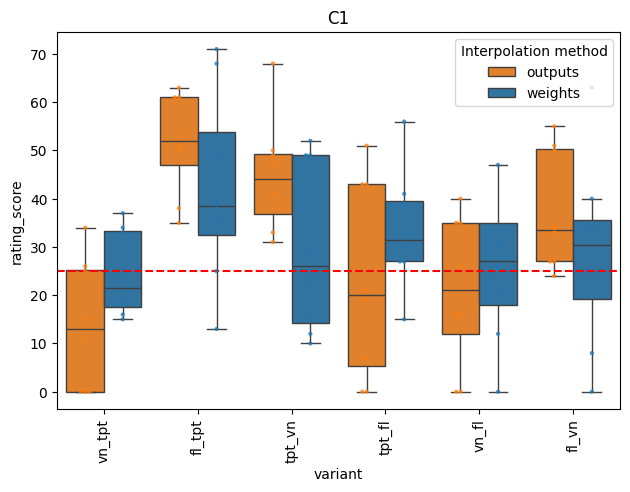

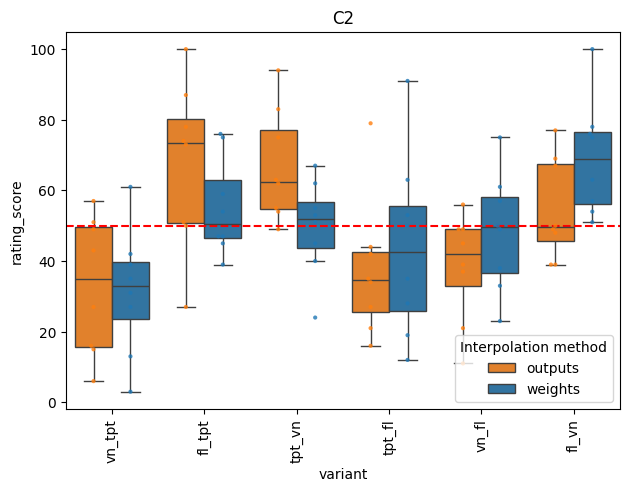

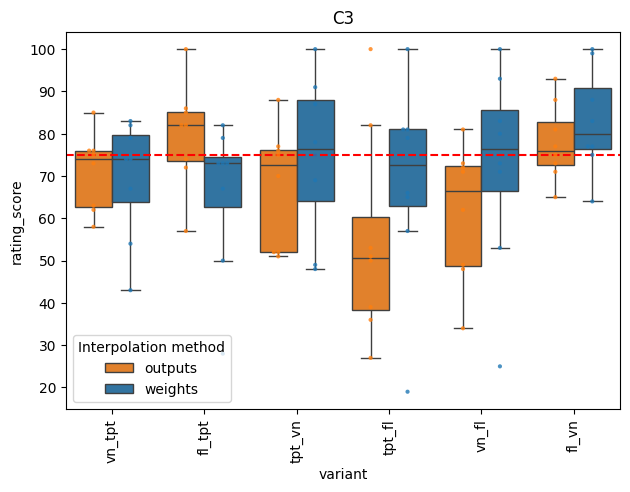

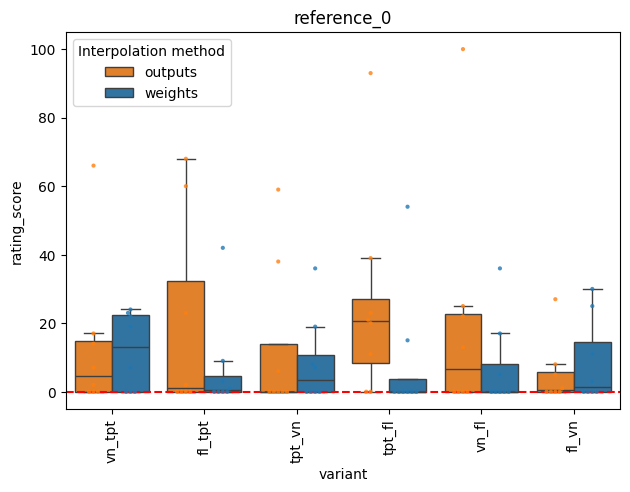

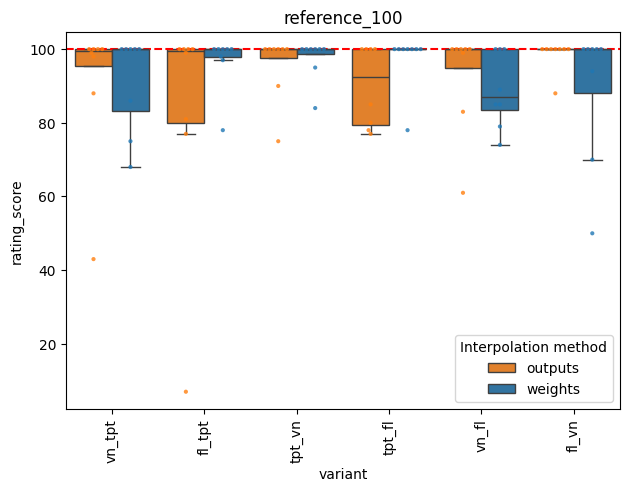

In [18]:
palette = {"weights": "#1f77b4", "outputs": "#ff7f0e"}

for stimulus in ["MOS", "C1", "C2", "C3", "reference_0", "reference_100"]:
    filt = df[
        (df['rating_stimulus'] == stimulus)
        & (df['trial_id'].str.contains("interpolate_(?:weights|outputs)", na=False))
    ].copy()

    filt['method'] = np.where(filt['trial_id'].str.contains("interpolate_weights", na=False), "weights", "outputs")
    filt['variant'] = filt['trial_id'].str.extract(r"interpolate_(?:weights|outputs)[-_]?(.+)$", expand=False).fillna(filt['trial_id'])

    fig, ax = plt.subplots()
    sns.boxplot(data=filt, x="variant", y="rating_score", hue="method", palette=palette, showfliers=False, ax=ax)
    sns.swarmplot(data=filt, x="variant", y="rating_score", hue="method", palette=palette, dodge=True, size=3, alpha=0.8, ax=ax, legend=False)

    if stimulus == "C1":
        ax.axhline(25, color="red", linestyle="--")
    elif stimulus == "C2":
        ax.axhline(50, color="red", linestyle="--")
    elif stimulus == "C3":
        ax.axhline(75, color="red", linestyle="--")
    elif stimulus == "reference_0":
        ax.axhline(0, color="red", linestyle="--")
    elif stimulus == "reference_100":
        ax.axhline(100, color="red", linestyle="--")

    plt.setp(ax.get_xticklabels(), rotation=90, ha='center')
    ax.legend(title="Interpolation method")
    plt.tight_layout()
    plt.title(stimulus)
    plt.show()


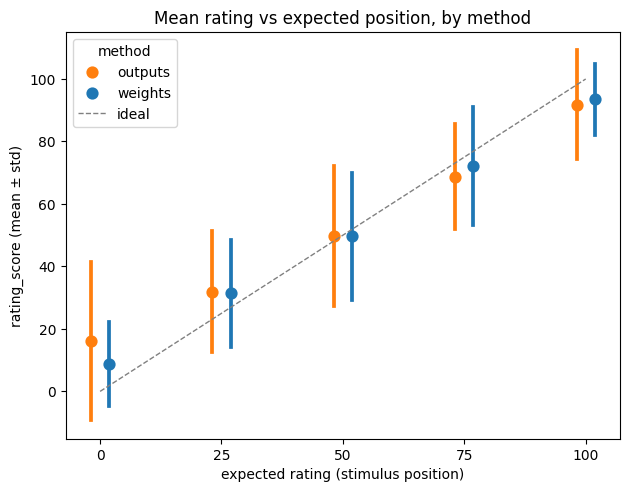

In [19]:
import numpy as np

palette = {"weights": "#1f77b4", "outputs": "#ff7f0e"}
stimulus_x = {"reference_0": 0, "C1": 25, "C2": 50, "C3": 75, "reference_100": 100}

filt = df[
    df['rating_stimulus'].isin(stimulus_x.keys())
    & df['trial_id'].str.contains("interpolate_(?:weights|outputs)", na=False)
].copy()

filt['method'] = np.where(filt['trial_id'].str.contains("interpolate_weights", na=False), "weights", "outputs")
filt['expected_x'] = filt['rating_stimulus'].map(stimulus_x)

fig, ax = plt.subplots()
sns.pointplot(
    data=filt, x="expected_x", y="rating_score", hue="method",
    palette=palette, errorbar="sd", dodge=0.15, linestyle="none",
    marker="o", ax=ax, order=sorted(stimulus_x.values())
)

# pointplot uses categorical x positions (0..n-1), so map the ideal line onto those same positions
xtick_vals = sorted(stimulus_x.values())
ax.plot(range(len(xtick_vals)), xtick_vals, color="gray", linestyle="--", linewidth=1, label="ideal")

ax.set_xlabel("expected rating (stimulus position)")
ax.set_ylabel("rating_score (mean ± std)")
ax.legend(title="method")
plt.tight_layout()
plt.title("Mean rating vs expected position, by method")
plt.show()

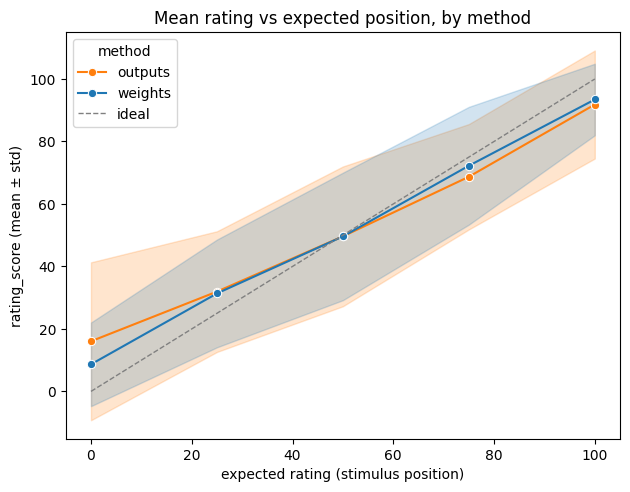

In [20]:
import numpy as np

palette = {"weights": "#1f77b4", "outputs": "#ff7f0e"}
stimulus_x = {"reference_0": 0, "C1": 25, "C2": 50, "C3": 75, "reference_100": 100}

filt = df[
    df['rating_stimulus'].isin(stimulus_x.keys())
    & df['trial_id'].str.contains("interpolate_(?:weights|outputs)", na=False)
].copy()

filt['method'] = np.where(filt['trial_id'].str.contains("interpolate_weights", na=False), "weights", "outputs")
filt['expected_x'] = filt['rating_stimulus'].map(stimulus_x)

fig, ax = plt.subplots()
sns.lineplot(
    data=filt, x="expected_x", y="rating_score", hue="method",
    palette=palette, errorbar="sd", marker="o", ax=ax
)

ax.plot([0, 100], [0, 100], color="gray", linestyle="--", linewidth=1, label="ideal")

ax.set_xlabel("expected rating (stimulus position)")
ax.set_ylabel("rating_score (mean ± std)")
ax.legend(title="method")
plt.tight_layout()
plt.title("Mean rating vs expected position, by method")
plt.show()

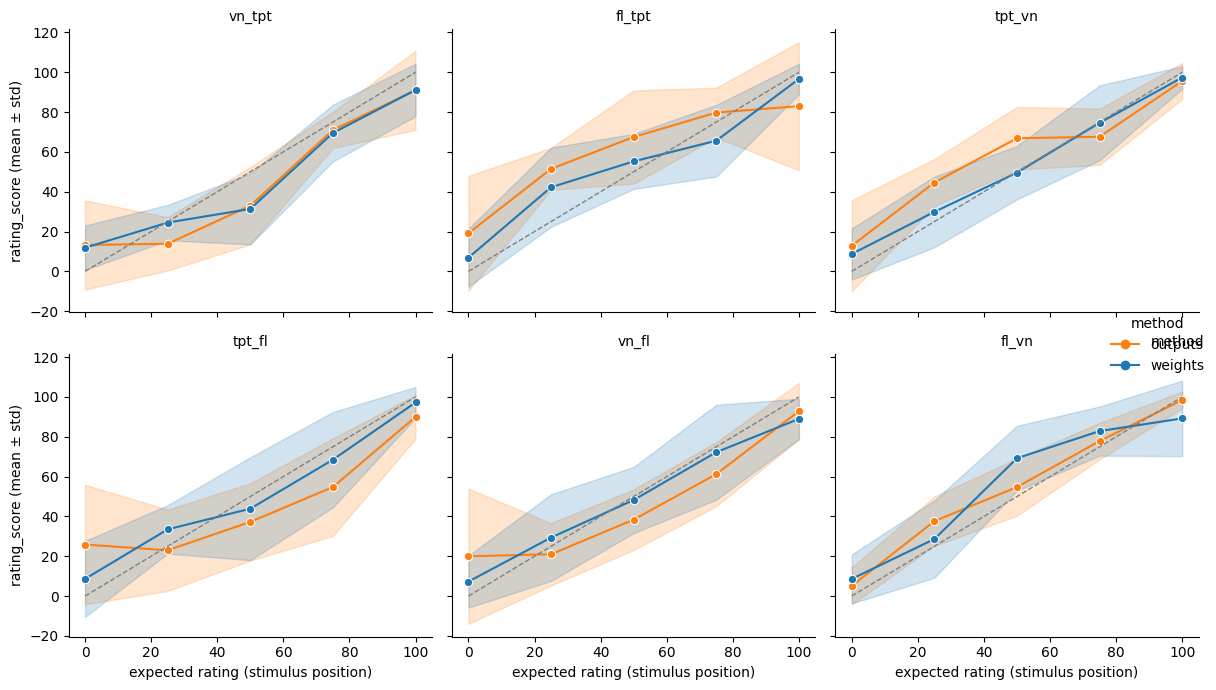

In [21]:
import numpy as np

palette = {"weights": "#1f77b4", "outputs": "#ff7f0e"}
stimulus_x = {"reference_0": 0, "C1": 25, "C2": 50, "C3": 75, "reference_100": 100}

filt = df[
    df['rating_stimulus'].isin(stimulus_x.keys())
    & df['trial_id'].str.contains("interpolate_(?:weights|outputs)", na=False)
].copy()

filt['method'] = np.where(filt['trial_id'].str.contains("interpolate_weights", na=False), "weights", "outputs")
filt['variant'] = filt['trial_id'].str.extract(r"interpolate_(?:weights|outputs)[-_]?(.+)$", expand=False).fillna(filt['trial_id'])
filt['expected_x'] = filt['rating_stimulus'].map(stimulus_x)

g = sns.relplot(
    data=filt, x="expected_x", y="rating_score", hue="method",
    col="variant", col_wrap=3, palette=palette, errorbar="sd",
    marker="o", kind="line", height=3.5, facet_kws={"sharex": True, "sharey": True}
)

for ax in g.axes.flat:
    ax.plot([0, 100], [0, 100], color="gray", linestyle="--", linewidth=1, label="ideal")

g.set_axis_labels("expected rating (stimulus position)", "rating_score (mean ± std)")
g.set_titles("{col_name}")
g.add_legend(title="method")
plt.tight_layout()
plt.show()